In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:

df = pd.read_csv(r"C:\Users\viraj\Downloads\swiggy_cleaned.csv")

# --- 1. DATA CLEANING ---

In [3]:

cleaned_df = df.copy()

In [4]:

for col in ['hotel_name', 'rating', 'time_minutes', 'food_type', 'location', 'offer_above', 'offer_percentage']:
    if col in cleaned_df.columns:
        cleaned_df[col] = cleaned_df[col].astype(str).str.strip()

In [5]:
# Fix swapped rating and delivery time 
mins_mask = cleaned_df['rating'].str.contains('mins', na=False)
extracted_time = cleaned_df.loc[mins_mask, 'rating'].str.extract(r'(\d+)')[0]

cleaned_df.loc[mins_mask, 'time_minutes'] = extracted_time
cleaned_df.loc[mins_mask, 'rating'] = np.nan

In [6]:
# Convert rating to float
cleaned_df['rating'] = pd.to_numeric(cleaned_df['rating'], errors='coerce')

In [7]:
# Parse time ranges
def parse_time(val):
    if pd.isna(val) or val == 'nan':
        return np.nan
    val_str = str(val).strip()
    if '-' in val_str:
        parts = val_str.split('-')
        try:
            return (float(parts[0]) + float(parts[1])) / 2.0
        except:
            return np.nan
    try:
        return float(val_str)
    except:
        return np.nan

cleaned_df['time_minutes'] = cleaned_df['time_minutes'].apply(parse_time)

In [8]:
# Convert offers to float
cleaned_df['offer_above'] = pd.to_numeric(cleaned_df['offer_above'], errors='coerce')
cleaned_df['offer_percentage'] = pd.to_numeric(cleaned_df['offer_percentage'], errors='coerce')

In [9]:

cleaned_df.to_csv('swiggy_fully_cleaned.csv', index=False)

# --- 2. VISUALIZATIONS ---

Text(0, 0.5, 'Count')

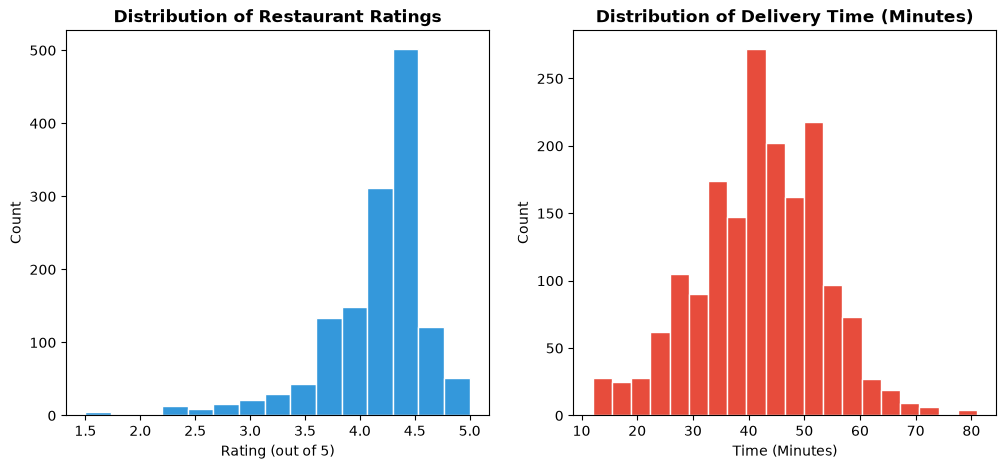

In [10]:


# Figure 1: Distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(cleaned_df['rating'].dropna(), bins=15, color='#3498db', edgecolor='white')
axes[0].set_title('Distribution of Restaurant Ratings', fontweight='bold')
axes[0].set_xlabel('Rating (out of 5)')
axes[0].set_ylabel('Count')

axes[1].hist(cleaned_df['time_minutes'].dropna(), bins=20, color='#e74c3c', edgecolor='white')
axes[1].set_title('Distribution of Delivery Time (Minutes)', fontweight='bold')
axes[1].set_xlabel('Time (Minutes)')
axes[1].set_ylabel('Count')


Text(0.5, 0, 'Frequency')

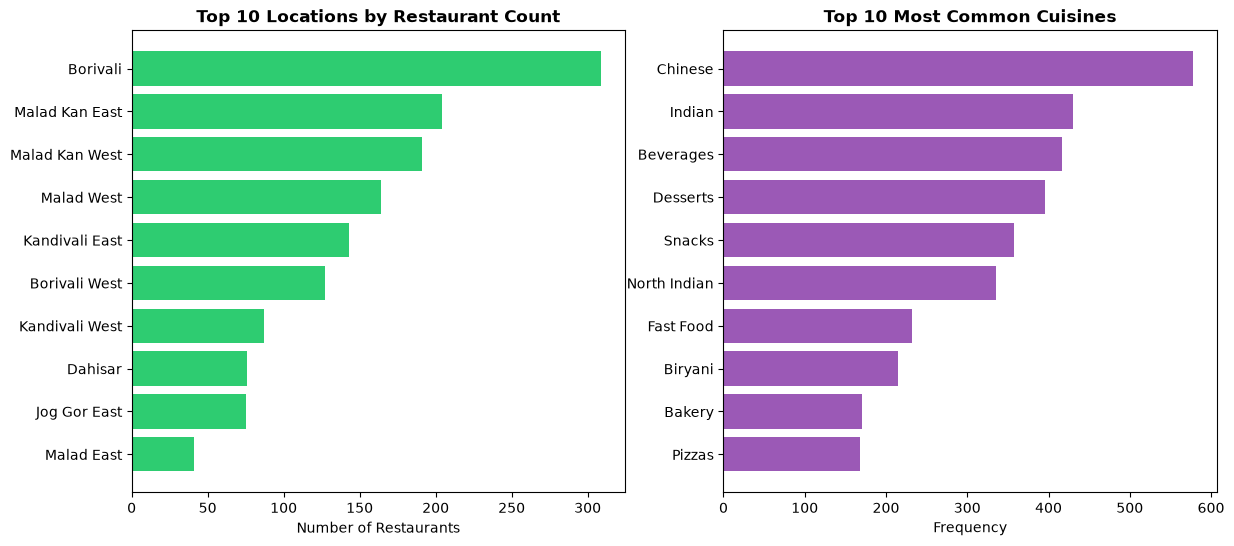

In [11]:
# Figure 2: Top Locations & Cuisines
top_locations = cleaned_df['location'].value_counts().head(10).sort_values(ascending=True)
cuisines = cleaned_df['food_type'].str.split(',').explode().str.strip()
top_cuisines = cuisines.value_counts().head(10).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top_locations.index, top_locations.values, color='#2ecc71')
axes[0].set_title('Top 10 Locations by Restaurant Count', fontweight='bold')
axes[0].set_xlabel('Number of Restaurants')

axes[1].barh(top_cuisines.index, top_cuisines.values, color='#9b59b6')
axes[1].set_title('Top 10 Most Common Cuisines', fontweight='bold')
axes[1].set_xlabel('Frequency')



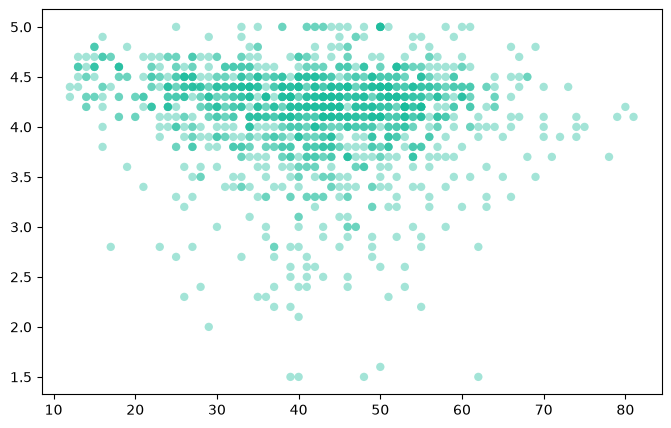

In [12]:
# Figure 3: Rating vs Delivery Time with Trendline
plt.figure(figsize=(8, 5))
valid_df = cleaned_df.dropna(subset=['time_minutes', 'rating'])
plt.scatter(valid_df['time_minutes'], valid_df['rating'], alpha=0.4, color='#1abc9c', edgecolors='none')


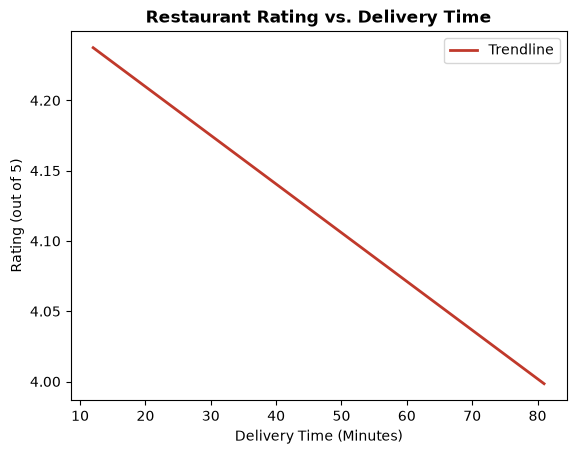

In [13]:
# Linear trendline fit
z = np.polyfit(valid_df['time_minutes'], valid_df['rating'], 1)
p = np.poly1d(z)
plt.plot(valid_df['time_minutes'].sort_values(), p(valid_df['time_minutes'].sort_values()), color='#c0392b', linewidth=2, label='Trendline')

plt.title('Restaurant Rating vs. Delivery Time', fontweight='bold')
plt.xlabel('Delivery Time (Minutes)')
plt.ylabel('Rating (out of 5)')
plt.legend()